# OND trigger design : one trigger across the riverine areas

Trigger spec (working group, Sep 2026):
- WHERE: the woredas the EDRMC Bega flood alert lists as at risk of riverine
  flooding in the Somali region: the middle and lower Wabi Shebelle (Kelafo,
  East Emi, Mustahil, Abakoro, Berokano, Adadile, Ferfer, Gode) and the lower
  Genale Dawa (Chereti, West Imi, Dolobay | Dolo Ado, Bokolomay, Filtu |
  Mubarek). Our 8 monitoring points sit on these reaches.
- WHEN: the OND season only (October to December, the Deyr window).
- SHAPE: one trigger across all areas, not per-station conditions.
- FREQUENCY: overall activation frequency of 1-in-3 years. With a single
  trigger and a single window, individual = overall = effective.

Method: on GloFAS v4 reanalysis (the version the operational forecast runs),
daily discharge at each station is compared with its own OND level for a
return period X (Gumbel on 2003-2025 OND maxima). A year activates when, on
at least one OND day, at least k stations (or k river systems) are at or
over their level. Sweep (rule, k, X); report Weibull RP = (n+1)/m over
2003-2025 (n = 23); target ~8 activation years. Validation: activation
years against the FloodScan flood record (satellite; impact side) per zone.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import ocha_stratus as stratus
import pandas as pd
from scipy import stats

STAGE = "dev"
PROJECT_PREFIX = "ds-aa-eth-flooding"
OND = [10, 11, 12]
YEARS = list(range(2003, 2026))
N_YEARS = len(YEARS)
RP_SWEEP = [1.5, 2, 2.5, 3, 4, 5, 7, 10]
VERSION = "v4_0"  # pinned to the operational forecast's scale

RIVER_OF = {
    "station_1": "Shabelle", "station_2": "Shabelle", "station_3": "Shabelle",
    "station_4": "Shabelle", "G1904": "Shabelle",
    "RP_4045_0535": "Genale", "RP_4205_0415": "Genale", "station_5": "Gestro",
}

## Load reanalysis (v4) and build daily OND series per station

In [2]:
frames = []
for blob in ["glofas_discharge.parquet", "glofas_discharge_reporting_points.parquet"]:
    df = stratus.load_parquet_from_blob(f"{PROJECT_PREFIX}/processed/glofas/{blob}", stage=STAGE)
    frames.append(df[df["dataset"] == "reanalysis"])
rean = pd.concat(frames, ignore_index=True)
rean["valid_time"] = pd.to_datetime(rean["valid_time"]).dt.normalize()
rean["date"] = rean["valid_time"] - pd.Timedelta(days=1)
rean = (
    rean.sort_values(["valid_time", "product_type"])
    .drop_duplicates(["station_id", "date"], keep="last")
)
ond = rean[rean["date"].dt.month.isin(OND) & rean["date"].dt.year.isin(YEARS)]
daily = ond.pivot_table(index="date", columns="station_id", values="discharge")
print(daily.shape, "days x stations |", daily.columns.tolist())

(2116, 8) days x stations | ['G1904', 'RP_4045_0535', 'RP_4205_0415', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5']


## OND levels per station for each candidate return period

Gumbel on the station's own OND maxima, 2003-2025 (reanalysis only).

In [3]:
levels = {}
for sid in daily.columns:
    am = daily[sid].groupby(daily.index.year).max().dropna()
    loc, scale = stats.gumbel_r.fit(am.values)
    levels[sid] = {rp: float(stats.gumbel_r.ppf(1 - 1 / rp, loc=loc, scale=scale)) for rp in RP_SWEEP}
pd.DataFrame(levels).T.round(0)

,1.5,2.0,2.5,3.0,4.0,5.0,7.0,10.0
G1904,843.0,930.0,988.0,1031.0,1096.0,1144.0,1214.0,1286.0
RP_4045_0535,450.0,502.0,537.0,563.0,602.0,631.0,673.0,716.0
RP_4205_0415,1454.0,1620.0,1730.0,1813.0,1937.0,2028.0,2161.0,2299.0
station_1,842.0,929.0,987.0,1030.0,1095.0,1143.0,1214.0,1286.0
station_2,843.0,930.0,987.0,1031.0,1096.0,1144.0,1214.0,1286.0
station_3,843.0,930.0,988.0,1031.0,1096.0,1144.0,1214.0,1286.0
station_4,843.0,930.0,988.0,1032.0,1097.0,1145.0,1215.0,1287.0
station_5,170.0,189.0,202.0,212.0,226.0,236.0,252.0,267.0


## Sweep the rule space

Two rule families, both one trigger across all areas:
- stations: at least k of the 8 stations over their level on the same day
- rivers: at least k of the 3 river systems over on the same day (a river is
  over when any of its stations is)

In [4]:
def activation_years(rp: float, k: int, by: str) -> list:
    lv = pd.Series({sid: levels[sid][rp] for sid in daily.columns})
    over = daily.ge(lv, axis=1)
    if by == "rivers":
        over = over.T.groupby(pd.Series(RIVER_OF)).any().T
    count = over.sum(axis=1)
    hit = count[count >= k]
    return sorted(hit.index.year.unique())


rows = []
for by, kmax in [("stations", 8), ("rivers", 3)]:
    for rp in RP_SWEEP:
        for k in range(1, kmax + 1):
            yrs = activation_years(rp, k, by)
            m = len(yrs)
            rows.append({
                "rule": by, "k": k, "station_rp": rp,
                "n_activations": m,
                "overall_rp": round((N_YEARS + 1) / m, 2) if m else np.inf,
                "years": ", ".join(str(y) for y in yrs),
            })
sweep = pd.DataFrame(rows)
target = sweep[sweep["overall_rp"].between(2.6, 3.5)].sort_values(["rule", "station_rp", "k"])
target

,rule,k,station_rp,n_activations,overall_rp,years
66,rivers,3,1.5,8,3.00,"2005, 2013, 2014, 2019, 2020, 2021, 2024, 2025"
71,rivers,2,2.5,8,3.00,"2006, 2007, 2012, 2013, 2014, 2019, 2023, 2024"
79,rivers,1,5.0,9,2.67,"2013, 2015, 2017, 2019, 2020, 2021, 2023, 2024..."
6,stations,7,1.5,8,3.00,"2005, 2013, 2014, 2019, 2020, 2021, 2024, 2025"
7,stations,8,1.5,7,3.43,"2005, 2014, 2019, 2020, 2021, 2024, 2025"
13,stations,6,2.0,8,3.00,"2007, 2012, 2013, 2014, 2019, 2020, 2021, 2024"
34,stations,3,4.0,8,3.00,"2007, 2010, 2013, 2014, 2019, 2020, 2023, 2024"
35,stations,4,4.0,7,3.43,"2007, 2010, 2013, 2014, 2019, 2020, 2024"
36,stations,5,4.0,7,3.43,"2007, 2010, 2013, 2014, 2019, 2020, 2024"
40,stations,1,5.0,9,2.67,"2013, 2015, 2017, 2019, 2020, 2021, 2023, 2024..."


## Validation against the FloodScan record

Impact-side check: FloodScan flood events (satellite flooded extent, events at
the zone's own RP2 and RP3 levels) in the three riverine zones, OND months,
2003-2025. For each candidate: which FloodScan flood years it catches and
which activations have no FloodScan flood.

In [5]:
fs_events = stratus.load_parquet_from_blob(
    f"{PROJECT_PREFIX}/processed/floodscan/floodscan_event_catalogue.parquet", stage=STAGE
)
fs_events["peak_date"] = pd.to_datetime(fs_events["peak_date"])
fs_ond = fs_events[fs_events["season"] == "deyr"]
fs_years = {
    rp: sorted(fs_ond[fs_ond["fs_rp"] == rp]["peak_date"].dt.year.unique())
    for rp in [2, 3]
}
print("FloodScan OND flood years (any riverine zone) | RP2:", fs_years[2], "| RP3:", fs_years[3])

val = []
for _, c in target.iterrows():
    yrs = set(int(y) for y in c["years"].split(", ")) if c["years"] else set()
    for fs_rp in [2, 3]:
        ref = set(fs_years[fs_rp])
        val.append({
            "rule": c["rule"], "k": c["k"], "station_rp": c["station_rp"],
            "overall_rp": c["overall_rp"], "fs_rp": fs_rp,
            "floods_caught": f"{len(yrs & ref)} of {len(ref)}",
            "activations_without_flood": len(yrs - ref),
        })
val = pd.DataFrame(val)
val.pivot_table(index=["rule", "station_rp", "k", "overall_rp"], columns="fs_rp",
                values="activations_without_flood", aggfunc="first")
val

FloodScan OND flood years (any riverine zone) | RP2: [np.int32(2004), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2011), np.int32(2013), np.int32(2015), np.int32(2017), np.int32(2021), np.int32(2022), np.int32(2023)] | RP3: [np.int32(2004), np.int32(2006), np.int32(2007), np.int32(2009), np.int32(2011), np.int32(2017), np.int32(2022), np.int32(2023)]


,rule,k,station_rp,overall_rp,fs_rp,floods_caught,activations_without_flood
0,rivers,3,1.5,3.00,2,2 of 12,6
1,rivers,3,1.5,3.00,3,0 of 8,8
2,rivers,2,2.5,3.00,2,4 of 12,4
3,rivers,2,2.5,3.00,3,3 of 8,5
4,rivers,1,5.0,2.67,2,5 of 12,4
5,rivers,1,5.0,2.67,3,2 of 8,7
6,stations,7,1.5,3.00,2,2 of 12,6
7,stations,7,1.5,3.00,3,0 of 8,8
8,stations,8,1.5,3.43,2,1 of 12,6
9,stations,8,1.5,3.43,3,0 of 8,7


## Activation years, candidate by candidate

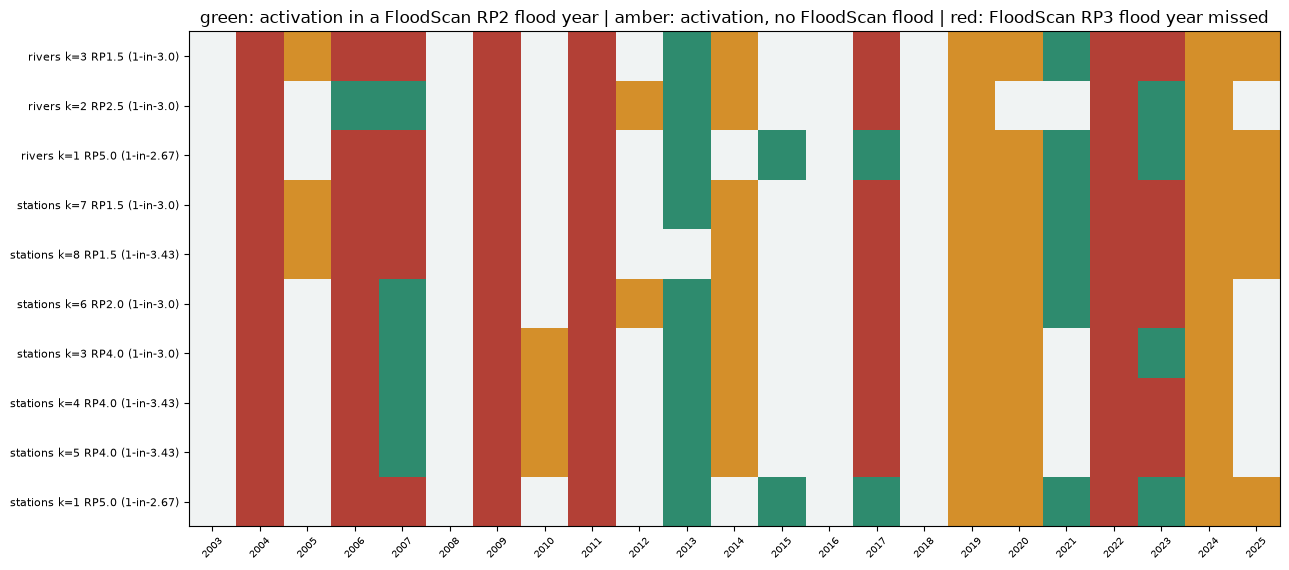

In [6]:
cands = target.reset_index(drop=True)
fig, ax = plt.subplots(figsize=(13, 0.42 * len(cands) + 1.6))
mat = np.zeros((len(cands), N_YEARS))
fs3 = set(fs_years[3]); fs2 = set(fs_years[2])
for i, c in cands.iterrows():
    yrs = set(int(y) for y in c["years"].split(", ")) if c["years"] else set()
    for j, y in enumerate(YEARS):
        act = y in yrs
        flood = y in fs2
        mat[i, j] = 1 if (act and flood) else 2 if act else 3 if y in fs3 else 0
ax.imshow(mat, cmap=mcolors.ListedColormap(["#f0f3f3", "#2E8B6E", "#D48F2A", "#B34036"]),
          vmin=0, vmax=3, aspect="auto")
ax.set_xticks(range(N_YEARS)); ax.set_xticklabels(YEARS, fontsize=7, rotation=45)
ax.set_yticks(range(len(cands)))
ax.set_yticklabels([f'{c["rule"]} k={c["k"]} RP{c["station_rp"]} (1-in-{c["overall_rp"]})'
                    for _, c in cands.iterrows()], fontsize=8)
ax.set_title("green: activation in a FloodScan RP2 flood year | amber: activation, no FloodScan flood | "
             "red: FloodScan RP3 flood year missed")
plt.tight_layout(); plt.show()

## Impact record, year by year: FloodScan, EM-DAT, CERF

Three records side by side for the OND season, 2003-2025:
- FloodScan: flood events in the three riverine zones (satellite flooded extent
  over the zone's own RP2 / RP3 level).
- EM-DAT: flood events in Ethiopia whose recorded locations name the Somali
  region riverine areas and whose dates touch OND. The blob snapshot is
  refreshed manually and can be stale for the newest years.
- CERF: allocations to Ethiopia with emergency type flood, by allocation year
  (national record: an allocation is not necessarily for these areas; the
  area column flags those whose title or emergency name mentions the region).

In [7]:
from ocha_stratus import emdat

AREA_WORDS = [
    "somali", "gode", "shabelle", "shebelle", "shabele", "kelafo", "mustahil",
    "ferfer", "afder", "liben", "liban", "dolo", "genale", "dawa", "imi", "chereti",
]

em = emdat.load_emdat_from_blob("ETH", include_historic=True, stage=STAGE)
em.columns = [c.lower().replace(" ", "_") for c in em.columns]
flood = em[em["disaster_type"].str.contains("Flood", case=False, na=False)].copy()
id_col = next(c for c in flood.columns if c.startswith("disno"))
loc_text = (
    flood["location"].fillna("") + " " + flood["admin_units"].fillna("").astype(str)
    + " " + flood["river_basin"].fillna("")
).str.lower()
flood["area_hit"] = loc_text.apply(lambda s: any(w in s for w in AREA_WORDS))
def touches_ond(r):
    months = set()
    sm = r.get("start_month"); em_ = r.get("end_month") or sm
    if pd.isna(sm):
        return False
    sm, em_ = int(sm), int(em_ if not pd.isna(em_) else sm)
    m = sm
    while True:
        months.add(m)
        if m == em_: break
        m = m % 12 + 1
        if len(months) > 12: break
    return bool(months & set(OND))
flood["ond"] = flood.apply(touches_ond, axis=1)
em_ond = flood[flood["area_hit"] & flood["ond"] & flood["start_year"].between(2003, 2025)]
emdat_by_year = em_ond.groupby("start_year").agg(
    emdat_events=(id_col, "count"), emdat_affected=("total_affected", "sum")
)
print(f"EM-DAT snapshot: {len(em)} ETH rows, latest start_year {em['start_year'].max():.0f}")
emdat_by_year

EM-DAT snapshot: 172 ETH rows, latest start_year 2025


,emdat_events,emdat_affected
start_year,,
2006,1,361600.0
2007,1,239586.0
2008,1,23831.0
2011,1,40200.0
2015,1,210600.0
2019,1,200000.0
2023,1,1500000.0


In [8]:
import requests

cerf_raw = requests.get(
    "https://cerfgms-webapi.unocha.org/v1/application/All.json", timeout=300
).json()
apps = pd.json_normalize(cerf_raw["application"] if "application" in cerf_raw else cerf_raw)
apps.columns = [c.lower() for c in apps.columns]
eth = apps[apps.get("countryname", pd.Series(dtype=str)).str.contains("Ethiopia", case=False, na=False)]
fl = eth[eth.filter(like="emergency").apply(
    lambda col: col.astype(str).str.contains("flood", case=False, na=False)
).any(axis=1)].copy()
year_col = next(c for c in ["year", "allocationyear", "applicationyear"] if c in fl.columns)
amount_col = next(c for c in ["totalamountapproved", "amountapproved", "totalamount"] if c in fl.columns)
title_col = next((c for c in ["applicationtitle", "title", "emergencyname"] if c in fl.columns), None)
fl["area_flag"] = fl[title_col].fillna("").str.lower().apply(
    lambda s: any(w in s for w in AREA_WORDS)
) if title_col else False
cerf_by_year = fl[fl[year_col].astype(int).between(2003, 2025)].groupby(fl[year_col].astype(int)).agg(
    cerf_allocations=(amount_col, "count"),
    cerf_usd=(amount_col, "sum"),
    cerf_mentions_area=("area_flag", "any"),
)
cerf_by_year

,cerf_allocations,cerf_usd,cerf_mentions_area
year,,,
2006,2,4994747.0,False
2018,1,5343942.0,False
2020,1,8000000.0,False
2023,1,8000001.0,False


In [9]:
impact = pd.DataFrame(index=YEARS)
impact["floodscan_rp2"] = [y in set(fs_years[2]) for y in YEARS]
impact["floodscan_rp3"] = [y in set(fs_years[3]) for y in YEARS]
impact = impact.join(emdat_by_year).join(cerf_by_year)
impact["emdat_events"] = impact["emdat_events"].fillna(0).astype(int)
impact["cerf_allocations"] = impact["cerf_allocations"].fillna(0).astype(int)
impact["cerf_usd"] = impact["cerf_usd"].fillna(0).round(0)
stratus.upload_parquet_to_blob(
    impact.reset_index(names="year"),
    f"{PROJECT_PREFIX}/processed/comparison/ond_impact_record.parquet", stage=STAGE,
)
impact

,floodscan_rp2,floodscan_rp3,emdat_events,emdat_affected,cerf_allocations,cerf_usd,cerf_mentions_area
2003,False,False,0,NaN,0,0.0,NaN
2004,True,True,0,NaN,0,0.0,NaN
2005,False,False,0,NaN,0,0.0,NaN
2006,True,True,1,361600.0,2,4994747.0,False
2007,True,True,1,239586.0,0,0.0,NaN
2008,True,False,1,23831.0,0,0.0,NaN
2009,True,True,0,NaN,0,0.0,NaN
2010,False,False,0,NaN,0,0.0,NaN
2011,True,True,1,40200.0,0,0.0,NaN
2012,False,False,0,NaN,0,0.0,NaN


## Save the sweep

In [10]:
stratus.upload_parquet_to_blob(
    sweep, f"{PROJECT_PREFIX}/processed/comparison/ond_trigger_sweep.parquet", stage=STAGE
)
print("saved processed/comparison/ond_trigger_sweep.parquet")

saved processed/comparison/ond_trigger_sweep.parquet
